# 🌿 Betel Leaf Disease Detection — Feature-Level Fusion (CNN + ViT)
**CSE 438 Group-4 | Fusion Method: Feature-Level Fusion — Experiment B**

---
## Pipeline Overview
| Step | Description |
|------|-------------|
| Step 1  | Install & Import Libraries |
| Step 2  | Dataset Download & Directory Setup |
| Step 3  | Data Exploration & Class Distribution |
| Step 4  | Data Augmentation & Transform |
| Step 5  | Dataset & DataLoader Creation |
| Step 6  | Feature-Level Fusion Model Building (CNN + ViT) |
| Step 7  | Training Loop with Validation |
| Step 8  | Training Curves Visualization |
| Step 9  | Final Test Evaluation & Metrics |
| Step 10 | Confusion Matrix & Per-Class Report |

---
## 🔀 What is Feature-Level Fusion?

```
                    Input Image [B, 3, 224, 224]
                          │
           ┌──────────────┴──────────────┐
           │                             │
    ResNet50 Backbone             ViT-Small Backbone
    (CNN: local texture)         (Transformer: global context)
           │                             │
    CNN Features [B, 2048]       ViT Features [B, 384]
           │                             │
           └──────────┬──────────────────┘
                      │  Concatenate
                      │
            Fused Features [B, 2432]
                      │
              Fusion Head
          Linear(2432 → 512) + ReLU + Dropout
          Linear(512 → num_classes)
                      │
              Predictions [B, 3]
```

> **PDF Reference:** Experiment B — Feature-level fusion (concat CNN + ViT features)  
> **PDF Step 3.4:** Connect two backbones → one new linear layer  
> **CNN Backbone:** ResNet50 (captures local texture & color patterns)  
> **ViT Backbone:** ViT-Small/16 (captures global spatial relationships)  
> **Fusion Point:** Intermediate feature vectors concatenated before final classifier


---
## ✅ Step 1 — Install & Import Libraries

In [1]:
import subprocess, sys
packages = ["timm", "scikit-learn", "matplotlib", "seaborn", "Pillow", "torchvision"]
for pkg in packages:
    result = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                            capture_output=True, text=True)
    print(f"[OK] {pkg}" if result.returncode == 0 else f"[FAIL] {pkg}: {result.stderr[:80]}")
print("\n✅ All packages ready!")

import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageFilter
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as tv_models
import timm

from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score)
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device  : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU     : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"   PyTorch : {torch.__version__}")
print(f"   timm    : {timm.__version__}")

[OK] timm
[OK] scikit-learn
[OK] matplotlib
[OK] seaborn
[OK] Pillow
[OK] torchvision

✅ All packages ready!

🖥️  Device  : cuda
   GPU     : Tesla T4
   VRAM    : 15.6 GB
   PyTorch : 2.10.0+cu128
   timm    : 1.0.25


---
## ✅ Step 2 — Dataset Download & Directory Setup

Dataset source: https://data.mendeley.com/datasets/vpzkntzjty/1  
> On Kaggle: **Add Data → Datasets** → search `"Comprehensive Betel Leaf Disease"` → add it.

In [2]:
CLASS_NAMES  = ["Healthy_Leaf", "Leaf_Rot", "Leaf_Spot"]
DATASET_ROOT = None

for root in ["/kaggle/input", "./data", "."]:
    for dirpath, dirnames, _ in os.walk(root):
        if "Original_Dataset" in dirnames:
            DATASET_ROOT = Path(dirpath) / "Original_Dataset"
            print(f"✅ Found Original_Dataset at: {DATASET_ROOT}")
            break
    if DATASET_ROOT: break

if DATASET_ROOT is None:
    print("⚠️  Original_Dataset not found — creating synthetic demo data...")
    DATASET_ROOT = Path("/kaggle/working/demo_dataset")
    for split in ["train", "val", "test"]:
        for cls in CLASS_NAMES:
            (DATASET_ROOT / split / cls).mkdir(parents=True, exist_ok=True)
            for i in range(40 if split == "train" else 12):
                img = Image.fromarray(np.random.randint(50, 200, (224, 224, 3), dtype=np.uint8))
                img.save(DATASET_ROOT / split / cls / f"img_{i:04d}.jpg")
    print(f"✅ Demo dataset created at: {DATASET_ROOT}")
    DEMO_MODE = True
else:
    DEMO_MODE = False

if not DEMO_MODE:
    from sklearn.model_selection import train_test_split
    import shutil
    SPLIT_ROOT = Path("/kaggle/working/split_dataset")
    if not SPLIT_ROOT.exists():
        print("\n📁 Creating train/val/test splits (70 / 15 / 15)...")
        for cls in CLASS_NAMES:
            all_imgs = (sorted((DATASET_ROOT / cls).glob("*.jpg")) +
                        sorted((DATASET_ROOT / cls).glob("*.png")) +
                        sorted((DATASET_ROOT / cls).glob("*.jpeg")))
            tr, temp = train_test_split(all_imgs, test_size=0.30, random_state=SEED)
            vl, te   = train_test_split(temp,     test_size=0.50, random_state=SEED)
            for split_name, imgs in [("train", tr), ("val", vl), ("test", te)]:
                dest = SPLIT_ROOT / split_name / cls
                dest.mkdir(parents=True, exist_ok=True)
                for src in imgs: shutil.copy(src, dest / src.name)
            print(f"   {cls:<15} → train:{len(tr):4d}  val:{len(vl):4d}  test:{len(te):4d}")
        print("✅ Splits ready!")
    DATASET_ROOT = SPLIT_ROOT

print("\n📊 Dataset Summary:")
for split in ["train", "val", "test"]:
    total = sum(len(list((DATASET_ROOT / split / c).glob("*.*")))
                for c in CLASS_NAMES if (DATASET_ROOT / split / c).exists())
    print(f"   {split:>5}: {total:5d} images")

# Config
IMG_SIZE        = 224
NUM_CLASSES     = len(CLASS_NAMES)
BATCH_SIZE      = 24    # Feature fusion uses 2 models — more VRAM
NUM_EPOCHS      = 20
LR              = 1e-4
NUM_WORKERS     = 2

# Feature dimensions
CNN_FEAT_DIM    = 2048  # ResNet50 global avg pool output
VIT_FEAT_DIM    = 384   # ViT-Small CLS token dim
FUSED_DIM       = CNN_FEAT_DIM + VIT_FEAT_DIM   # 2432
FUSION_HIDDEN   = 512   # fusion head hidden size

MODEL_NAME = "Feature-Fusion (ResNet50 + ViT-Small)"
PREFIX     = "feat_fusion"

print(f"\n⚙️  Config:")
print(f"   IMG={IMG_SIZE}  Classes={NUM_CLASSES}  Batch={BATCH_SIZE}  Epochs={NUM_EPOCHS}  LR={LR}")
print(f"   CNN features   : {CNN_FEAT_DIM}  (ResNet50)")
print(f"   ViT features   : {VIT_FEAT_DIM}  (ViT-Small)")
print(f"   Fused dim      : {FUSED_DIM}  (concatenated)")
print(f"   Fusion hidden  : {FUSION_HIDDEN}")

✅ Found Original_Dataset at: /kaggle/input/datasets/mikeafridi/cse-438-group-4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset

📁 Creating train/val/test splits (70 / 15 / 15)...
   Healthy_Leaf    → train: 756  val: 162  test: 162
   Leaf_Rot        → train: 188  val:  40  test:  41
   Leaf_Spot       → train: 481  val: 103  test: 104
✅ Splits ready!

📊 Dataset Summary:
   train:  1425 images
     val:   305 images
    test:   307 images

⚙️  Config:
   IMG=224  Classes=3  Batch=24  Epochs=20  LR=0.0001
   CNN features   : 2048  (ResNet50)
   ViT features   : 384  (ViT-Small)
   Fused dim      : 2432  (concatenated)
   Fusion hidden  : 512


---
## ✅ Step 3 — Data Exploration & Class Distribution

📊 Class Distribution Table
Split         test  train  val
Class                         
Healthy_Leaf   162    756  162
Leaf_Rot        41    188   40
Leaf_Spot      104    481  103


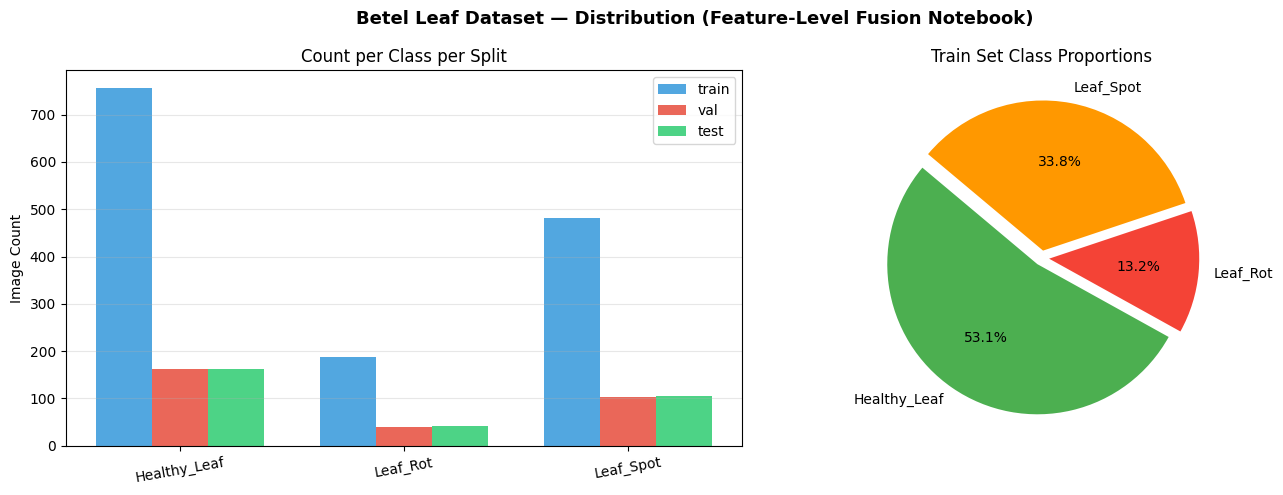

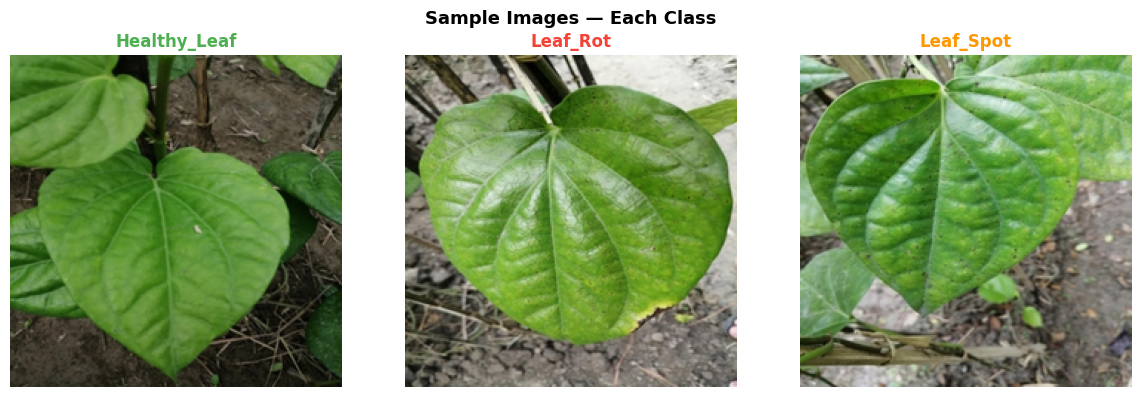

✅ Step 3 complete.


In [3]:
records = []
for split in ["train", "val", "test"]:
    for cls in CLASS_NAMES:
        folder = DATASET_ROOT / split / cls
        if folder.exists():
            imgs = (list(folder.glob("*.jpg")) + list(folder.glob("*.png")) +
                    list(folder.glob("*.jpeg")))
            records.append({"Split": split, "Class": cls, "Count": len(imgs)})

df_dist = pd.DataFrame(records)
print("📊 Class Distribution Table")
print(df_dist.pivot(index="Class", columns="Split", values="Count").fillna(0).astype(int))

colors = ["#4CAF50", "#F44336", "#FF9800"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Betel Leaf Dataset — Distribution (Feature-Level Fusion Notebook)",
             fontsize=13, fontweight="bold")

ax = axes[0]
x = np.arange(len(CLASS_NAMES)); w = 0.25
for i, (split, col) in enumerate(zip(["train", "val", "test"],
                                      ["#3498db", "#e74c3c", "#2ecc71"])):
    vals = [df_dist[(df_dist.Split == split) & (df_dist.Class == c)]["Count"].sum()
            for c in CLASS_NAMES]
    ax.bar(x + i * w, vals, w, label=split, color=col, alpha=0.85)
ax.set_xticks(x + w); ax.set_xticklabels(CLASS_NAMES, rotation=10)
ax.set_title("Count per Class per Split"); ax.set_ylabel("Image Count")
ax.legend(); ax.grid(axis="y", alpha=0.3)

ax2 = axes[1]
train_counts = [df_dist[(df_dist.Split == "train") & (df_dist.Class == c)]["Count"].sum()
                for c in CLASS_NAMES]
ax2.pie(train_counts, labels=CLASS_NAMES, colors=colors, autopct="%1.1f%%",
        startangle=140, explode=[0.05] * 3)
ax2.set_title("Train Set Class Proportions")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step3_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
fig2.suptitle("Sample Images — Each Class", fontsize=13, fontweight="bold")
for ax, cls, color in zip(axes2, CLASS_NAMES, colors):
    folder = DATASET_ROOT / "train" / cls
    sample = list(folder.glob("*.*"))[0]
    ax.imshow(Image.open(sample).resize((224, 224)))
    ax.set_title(cls, color=color, fontweight="bold"); ax.axis("off")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step3_samples.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Step 3 complete.")

---
## ✅ Step 4 — Data Augmentation & Transform

**Feature-Level Fusion** uses a **single standard RGB transform** — no channel concatenation needed here.  
Both CNN and ViT branches receive the **same image** `[B, 3, 224, 224]` as input.  
Each backbone independently extracts its own feature representation.

```
Same Image [B, 3, 224, 224]
       ├──→  ResNet50  →  CNN features [B, 2048]
       └──→  ViT-Small →  ViT features [B, 384]
                    Concat → [B, 2432] → Head
```

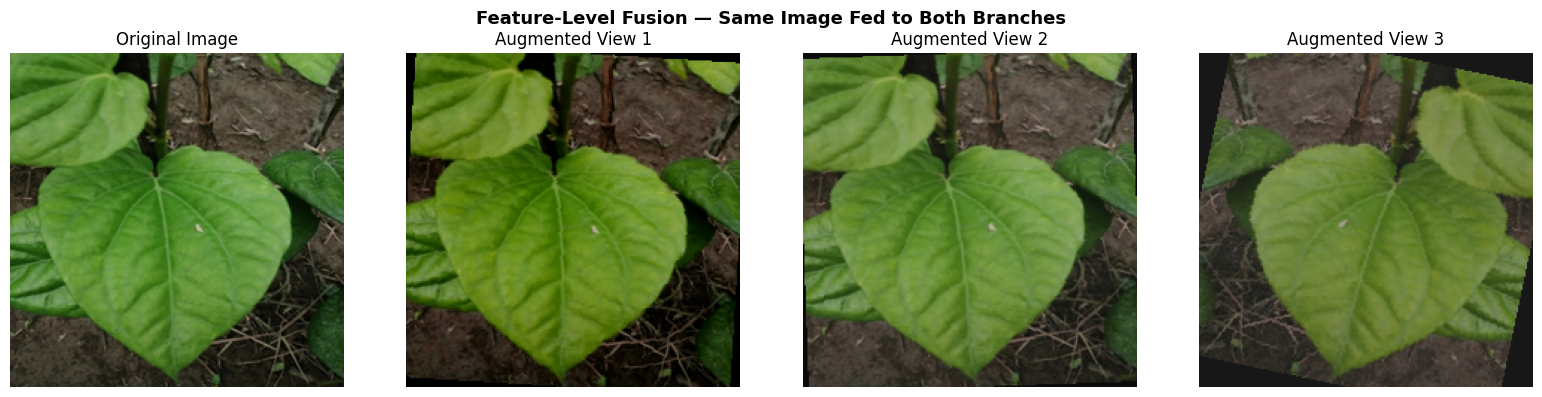

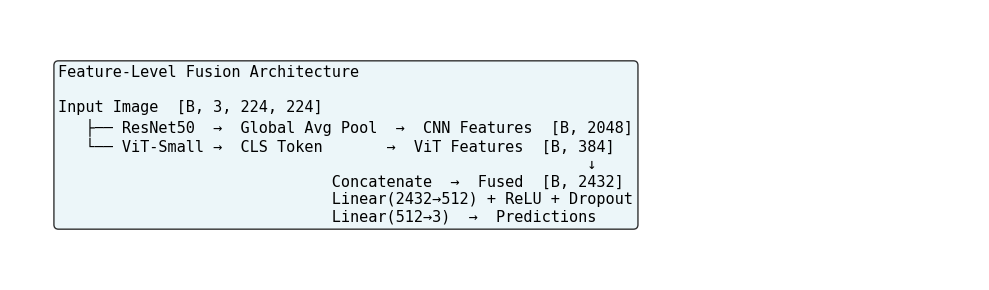

✅ Step 4 complete — Standard RGB transform ready
   Input shape to both branches: [B, 3, 224, 224]


In [4]:
# Standard RGB transform — no 4-channel fusion needed here
# Both branches receive the same 3-channel image

MEAN_RGB = [0.485, 0.456, 0.406]
STD_RGB  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # PDF Phase 1 augmentation: rotate ±15°, flip, brightness/contrast
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN_RGB, STD_RGB),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN_RGB, STD_RGB),
])

# Visualize transform pipeline
sample_path = list((DATASET_ROOT / "train" / CLASS_NAMES[0]).glob("*.*"))[0]
sample_pil  = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Feature-Level Fusion — Same Image Fed to Both Branches",
             fontsize=13, fontweight="bold")

# Original
axes[0].imshow(sample_pil.resize((224, 224)))
axes[0].set_title("Original Image"); axes[0].axis("off")

# Augmented views (train transform applied 3 times)
for i in range(1, 4):
    aug_t = train_transform(sample_pil)   # [3, 224, 224]
    # Denormalize for display
    mean = torch.tensor(MEAN_RGB).view(3,1,1)
    std  = torch.tensor(STD_RGB).view(3,1,1)
    disp = (aug_t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[i].imshow(disp)
    axes[i].set_title(f"Augmented View {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step4_augmentation.png", dpi=120, bbox_inches="tight")
plt.show()

# Show dual-path concept
fig2, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")
info_text = (
    "Feature-Level Fusion Architecture\n\n"
    f"Input Image  [B, 3, {IMG_SIZE}, {IMG_SIZE}]\n"
    f"   ├── ResNet50  →  Global Avg Pool  →  CNN Features  [B, {CNN_FEAT_DIM}]\n"
    f"   └── ViT-Small →  CLS Token       →  ViT Features  [B, {VIT_FEAT_DIM}]\n"
    f"                                                          ↓\n"
    f"                              Concatenate  →  Fused  [B, {FUSED_DIM}]\n"
    f"                              Linear({FUSED_DIM}→{FUSION_HIDDEN}) + ReLU + Dropout\n"
    f"                              Linear({FUSION_HIDDEN}→{NUM_CLASSES})  →  Predictions"
)
ax.text(0.05, 0.5, info_text, transform=ax.transAxes,
        fontfamily="monospace", fontsize=11, va="center",
        bbox=dict(boxstyle="round", facecolor="#e8f4f8", alpha=0.8))
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step4_architecture.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"✅ Step 4 complete — Standard RGB transform ready")
print(f"   Input shape to both branches: [B, 3, {IMG_SIZE}, {IMG_SIZE}]")

---
## ✅ Step 5 — Dataset & DataLoader Creation

In [5]:
class BetelLeafDataset(Dataset):
    """Standard RGB dataset — same image fed to both CNN and ViT branches."""
    def __init__(self, root_dir, class_names, transform=None):
        self.class_names  = class_names
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.transform    = transform
        self.samples      = []
        for cls in class_names:
            folder = Path(root_dir) / cls
            if not folder.exists(): continue
            for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG"]:
                for p in sorted(folder.glob(ext)):
                    self.samples.append((str(p), self.class_to_idx[cls]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:    img = Image.open(path).convert("RGB")
        except: img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
        if self.transform: img = self.transform(img)
        return img, label


train_ds = BetelLeafDataset(DATASET_ROOT / "train", CLASS_NAMES, train_transform)
val_ds   = BetelLeafDataset(DATASET_ROOT / "val",   CLASS_NAMES, val_transform)
test_ds  = BetelLeafDataset(DATASET_ROOT / "test",  CLASS_NAMES, val_transform)
print(f"📦 Sizes → Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

# WeightedRandomSampler — handles class imbalance (PDF Phase 1)
labels_train = [s[1] for s in train_ds.samples]
class_counts = Counter(labels_train)
weights      = [1.0 / class_counts[l] for l in labels_train]
sampler      = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

batch_imgs, batch_labels = next(iter(train_loader))
print(f"\n🔍 Batch check:")
print(f"   Image tensor : {batch_imgs.shape}  (B × 3 × H × W)")
print(f"   Labels       : {batch_labels[:8].tolist()}")
print(f"   Value range  : [{batch_imgs.min():.3f}, {batch_imgs.max():.3f}]")
print("\n✅ Step 5 complete — DataLoaders ready!")

📦 Sizes → Train: 1425  Val: 305  Test: 307

🔍 Batch check:
   Image tensor : torch.Size([24, 3, 224, 224])  (B × 3 × H × W)
   Labels       : [1, 0, 2, 2, 1, 0, 2, 1]
   Value range  : [-2.118, 2.640]

✅ Step 5 complete — DataLoaders ready!


---
## ✅ Step 6 — Feature-Level Fusion Model Building

**PDF Experiment B + Step 3.4:** Connect two backbones → one new linear layer

### Architecture
```
Input [B, 3, 224, 224]
       │
  ┌────┴────┐
  │         │
ResNet50  ViT-Small/16
  │         │
  │  GAP    │  CLS token
  │         │
[B,2048] [B,384]
  │         │
  └────┬────┘
    Concat
  [B, 2432]
       │
  Linear(2432→512)
       │
    ReLU + BN
       │
   Dropout(0.4)
       │
  Linear(512→3)
       │
  Predictions
```

**Key design choices:**
- ResNet50 → extracts **local CNN features** (edges, textures, colors, shapes)
- ViT-Small → extracts **global attention features** (long-range spatial relationships)
- Both backbones are **frozen for first 3 epochs**, then **unfrozen** (gradual unfreezing)
- Fusion head is a 2-layer MLP with BatchNorm for stable training

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Feature-Level Fusion Model: ResNet50 (CNN) + ViT-Small (Transformer)
# PDF Step 3.4 — Feature fusion: connect two backbones → one new linear layer
# ═══════════════════════════════════════════════════════════════════════════

class CNNBranch(nn.Module):
    """
    CNN Branch: ResNet50 backbone
    - Load pretrained ResNet50
    - Remove final FC layer
    - Output: Global Average Pooled features [B, 2048]
    """
    def __init__(self):
        super().__init__()
        backbone = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
        # Remove the final FC layer — keep everything up to global avg pool
        self.features = nn.Sequential(*list(backbone.children())[:-1])  # output: [B, 2048, 1, 1]

    def forward(self, x):   # x: [B, 3, 224, 224]
        feat = self.features(x)            # [B, 2048, 1, 1]
        return feat.flatten(1)             # [B, 2048]


class ViTBranch(nn.Module):
    """
    ViT Branch: ViT-Small/16 backbone
    - Load pretrained ViT-Small/16 via timm
    - Remove classification head
    - Output: CLS token features [B, 384]
    """
    def __init__(self):
        super().__init__()
        # num_classes=0 → timm removes head, returns feature vector directly
        self.backbone = timm.create_model(
            "vit_small_patch16_224",
            pretrained=True,
            num_classes=0   # remove head → forward returns [B, 384] directly
        )

    def forward(self, x):   # x: [B, 3, 224, 224]
        return self.backbone(x)            # [B, 384] — CLS token embedding


class FusionHead(nn.Module):
    """
    Fusion Head: MLP that takes concatenated CNN+ViT features
    Input:  [B, 2432]  (2048 + 384)
    Output: [B, num_classes]
    Architecture: Linear → BN → ReLU → Dropout → Linear
    """
    def __init__(self, in_dim, hidden_dim, num_classes, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)


class FeatureLevelFusionModel(nn.Module):
    """
    Feature-Level Fusion Model (PDF Experiment B):

    1. CNN Branch  (ResNet50)  → local feature vector  [B, 2048]
    2. ViT Branch  (ViT-Small) → global feature vector [B, 384]
    3. Concatenate             → fused vector          [B, 2432]
    4. Fusion Head (MLP)       → class logits          [B, num_classes]

    Training strategy:
    - Phase 1 (epoch 1-3) : freeze both backbones, train fusion head only
    - Phase 2 (epoch 4+)  : unfreeze all layers, fine-tune end-to-end
    """
    def __init__(self, num_classes=3, fusion_hidden=512, dropout=0.4):
        super().__init__()
        self.cnn_branch   = CNNBranch()
        self.vit_branch   = ViTBranch()
        self.fusion_head  = FusionHead(
            in_dim=CNN_FEAT_DIM + VIT_FEAT_DIM,
            hidden_dim=fusion_hidden,
            num_classes=num_classes,
            dropout=dropout
        )

    def freeze_backbones(self):
        """Freeze both backbone branches (train head only)."""
        for p in self.cnn_branch.parameters():  p.requires_grad = False
        for p in self.vit_branch.parameters():  p.requires_grad = False
        for p in self.fusion_head.parameters(): p.requires_grad = True
        print("🔒 Backbones FROZEN — training fusion head only")

    def unfreeze_all(self):
        """Unfreeze everything for end-to-end fine-tuning."""
        for p in self.parameters(): p.requires_grad = True
        print("🔓 All layers UNFROZEN — end-to-end fine-tuning")

    def forward(self, x):   # x: [B, 3, 224, 224]
        cnn_feat  = self.cnn_branch(x)                           # [B, 2048]
        vit_feat  = self.vit_branch(x)                           # [B, 384]
        fused     = torch.cat([cnn_feat, vit_feat], dim=1)       # [B, 2432]
        logits    = self.fusion_head(fused)                      # [B, num_classes]
        return logits


# Instantiate
model = FeatureLevelFusionModel(
    num_classes=NUM_CLASSES,
    fusion_hidden=FUSION_HIDDEN,
    dropout=0.4
).to(DEVICE)

# Parameter count
total_p     = sum(p.numel() for p in model.parameters())
cnn_p       = sum(p.numel() for p in model.cnn_branch.parameters())
vit_p       = sum(p.numel() for p in model.vit_branch.parameters())
head_p      = sum(p.numel() for p in model.fusion_head.parameters())

print(f"🏗️  Model Architecture: Feature-Level Fusion")
print(f"")
print(f"   CNN Branch  (ResNet50)     : {cnn_p:>12,} params")
print(f"   ViT Branch  (ViT-Small/16) : {vit_p:>12,} params")
print(f"   Fusion Head (MLP)          : {head_p:>12,} params")
print(f"   {'─'*45}")
print(f"   Total params               : {total_p:>12,}")
print(f"")
print(f"   CNN features  : [B, {CNN_FEAT_DIM}]")
print(f"   ViT features  : [B, {VIT_FEAT_DIM}]")
print(f"   Fused         : [B, {FUSED_DIM}]")
print(f"   Output        : [B, {NUM_CLASSES}]")

# Forward pass verification
model.eval()
with torch.no_grad():
    dummy     = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    # Check each branch independently
    cnn_out   = model.cnn_branch(dummy)
    vit_out   = model.vit_branch(dummy)
    full_out  = model(dummy)
print(f"\n✅ Forward pass OK:")
print(f"   CNN branch output : {cnn_out.shape}")
print(f"   ViT branch output : {vit_out.shape}")
print(f"   Full model output : {full_out.shape}")

# Loss, Optimizer, Scheduler (PDF Phase 3)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Separate LRs: lower for pretrained backbones, higher for new fusion head
optimizer = optim.AdamW([
    {"params": model.cnn_branch.parameters(),  "lr": LR * 0.1},   # 1e-5 — pretrained CNN
    {"params": model.vit_branch.parameters(),  "lr": LR * 0.05},  # 5e-6 — pretrained ViT (lower)
    {"params": model.fusion_head.parameters(), "lr": LR},          # 1e-4 — new head (higher)
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

print(f"\n⚙️  Loss      : CrossEntropyLoss(label_smoothing=0.1)")
print(f"   Optimizer : AdamW with 3 param groups:")
print(f"     CNN backbone  LR = {LR*0.1:.2e}")
print(f"     ViT backbone  LR = {LR*0.05:.2e}")
print(f"     Fusion head   LR = {LR:.2e}")
print(f"   Scheduler : CosineAnnealing(T_max={NUM_EPOCHS})")
print(f"   Training  : Phase1 (ep 1-3 backbone frozen) → Phase2 (ep 4+ full finetune)")
print("\n✅ Step 6 complete — Feature-Level Fusion model ready!")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

🏗️  Model Architecture: Feature-Level Fusion

   CNN Branch  (ResNet50)     :   23,508,032 params
   ViT Branch  (ViT-Small/16) :   21,665,664 params
   Fusion Head (MLP)          :    1,248,259 params
   ─────────────────────────────────────────────
   Total params               :   46,421,955

   CNN features  : [B, 2048]
   ViT features  : [B, 384]
   Fused         : [B, 2432]
   Output        : [B, 3]

✅ Forward pass OK:
   CNN branch output : torch.Size([2, 2048])
   ViT branch output : torch.Size([2, 384])
   Full model output : torch.Size([2, 3])

⚙️  Loss      : CrossEntropyLoss(label_smoothing=0.1)
   Optimizer : AdamW with 3 param groups:
     CNN backbone  LR = 1.00e-05
     ViT backbone  LR = 5.00e-06
     Fusion head   LR = 1.00e-04
   Scheduler : CosineAnnealing(T_max=20)
   Training  : Phase1 (ep 1-3 backbone frozen) → Phase2 (ep 4+ full finetune)

✅ Step 6 complete — Feature-Level Fusion model ready!


---
## ✅ Step 7 — Training Loop with Validation

**PDF Phase 4 + Phase 5 (Feature Fusion variant):**
- **Phase 1 (Epoch 1–3):** Backbones frozen → only fusion head trains → fast convergence
- **Phase 2 (Epoch 4+):** All layers unfrozen → end-to-end fine-tuning with lower LR
- Save best model (lowest val loss)
- Early stopping (patience = 7)

In [7]:
CKPT_PATH   = f"/kaggle/working/best_{PREFIX}_model.pth"
UNFREEZE_EP = 3   # after this epoch, unfreeze backbones

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs     = model(imgs)
        total_loss += criterion(outputs, labels).item() * imgs.size(0)
        preds       = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels))


# Phase 1: Start with frozen backbones
model.freeze_backbones()

history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
    "val_f1":     [], "lr_head":  [],
    "phase":      []   # track which training phase each epoch belongs to
}
best_val_loss = float("inf")
best_val_acc  = 0.0
patience      = 7
no_improve    = 0
phase         = 1  # 1 = head only, 2 = full finetune

print(f"🚀 Training Feature-Level Fusion for {NUM_EPOCHS} epochs on {DEVICE}")
print(f"   Phase 1 (ep 1-{UNFREEZE_EP}): backbone frozen  → train fusion head only")
print(f"   Phase 2 (ep {UNFREEZE_EP+1}+): full finetune  → all layers trainable")
print()
print(f"{'Ep':>4} {'Ph':>3} {'TrLoss':>8} {'TrAcc':>8} {'VaLoss':>8} "
      f"{'VaAcc':>8} {'VaF1':>7} {'HeadLR':>10}")
print("-" * 72)

start_total = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ── Phase transition: unfreeze after UNFREEZE_EP epochs ───────────────
    if epoch == UNFREEZE_EP + 1 and phase == 1:
        model.unfreeze_all()
        phase = 2
        print(f"\n{'─'*72}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_preds, val_true = evaluate(model, val_loader, criterion, DEVICE)
    val_f1   = f1_score(val_true, val_preds, average="weighted", zero_division=0)
    head_lr  = optimizer.param_groups[2]["lr"]   # fusion head LR (group index 2)
    scheduler.step()

    for k, v in zip(
        ["train_loss", "val_loss", "train_acc", "val_acc", "val_f1", "lr_head", "phase"],
        [train_loss,    val_loss,   train_acc,   val_acc,   val_f1,   head_lr,   phase]):
        history[k].append(v)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss; best_val_acc = val_acc
        torch.save({
            "epoch":               epoch,
            "model_state_dict":    model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss":            val_loss,
            "val_acc":             val_acc,
            "val_f1":              val_f1,
            "phase":               phase
        }, CKPT_PATH)
        no_improve = 0; marker = " ✓"
    else:
        no_improve += 1

    ph_label = "🔒" if phase == 1 else "🔓"
    print(f"{epoch:>4} {ph_label} {train_loss:>8.4f} {train_acc*100:>7.2f}% "
          f"{val_loss:>8.4f} {val_acc*100:>7.2f}% "
          f"{val_f1:>7.4f} {head_lr:>10.2e}  ({time.time()-t0:.1f}s){marker}")

    if no_improve >= patience:
        print(f"\n⏹️  Early stopping at epoch {epoch}"); break

print(f"\n✅ Training done in {(time.time()-start_total)/60:.1f} min")
print(f"   Best val loss : {best_val_loss:.4f}")
print(f"   Best val acc  : {best_val_acc*100:.2f}%")

🔒 Backbones FROZEN — training fusion head only
🚀 Training Feature-Level Fusion for 20 epochs on cuda
   Phase 1 (ep 1-3): backbone frozen  → train fusion head only
   Phase 2 (ep 4+): full finetune  → all layers trainable

  Ep  Ph   TrLoss    TrAcc   VaLoss    VaAcc    VaF1     HeadLR
------------------------------------------------------------------------
   1 🔒   0.7082   75.86%   0.5871   83.61%  0.8432   1.00e-04  (17.4s) ✓
   2 🔒   0.5489   87.16%   0.5832   84.92%  0.8549   9.94e-05  (16.8s) ✓
   3 🔒   0.5391   87.23%   0.5515   85.57%  0.8577   9.76e-05  (16.9s) ✓
🔓 All layers UNFROZEN — end-to-end fine-tuning

────────────────────────────────────────────────────────────────────────
   4 🔓   0.4872   90.95%   0.5390   87.54%  0.8745   9.46e-05  (33.7s) ✓
   5 🔓   0.4743   92.00%   0.4988   90.49%  0.9042   9.05e-05  (36.5s) ✓
   6 🔓   0.4442   93.40%   0.4956   91.15%  0.9114   8.54e-05  (37.3s) ✓
   7 🔓   0.4444   92.98%   0.4862   91.80%  0.9172   7.94e-05  (36.4s) ✓
   8 🔓  

---
## ✅ Step 8 — Training Curves Visualization

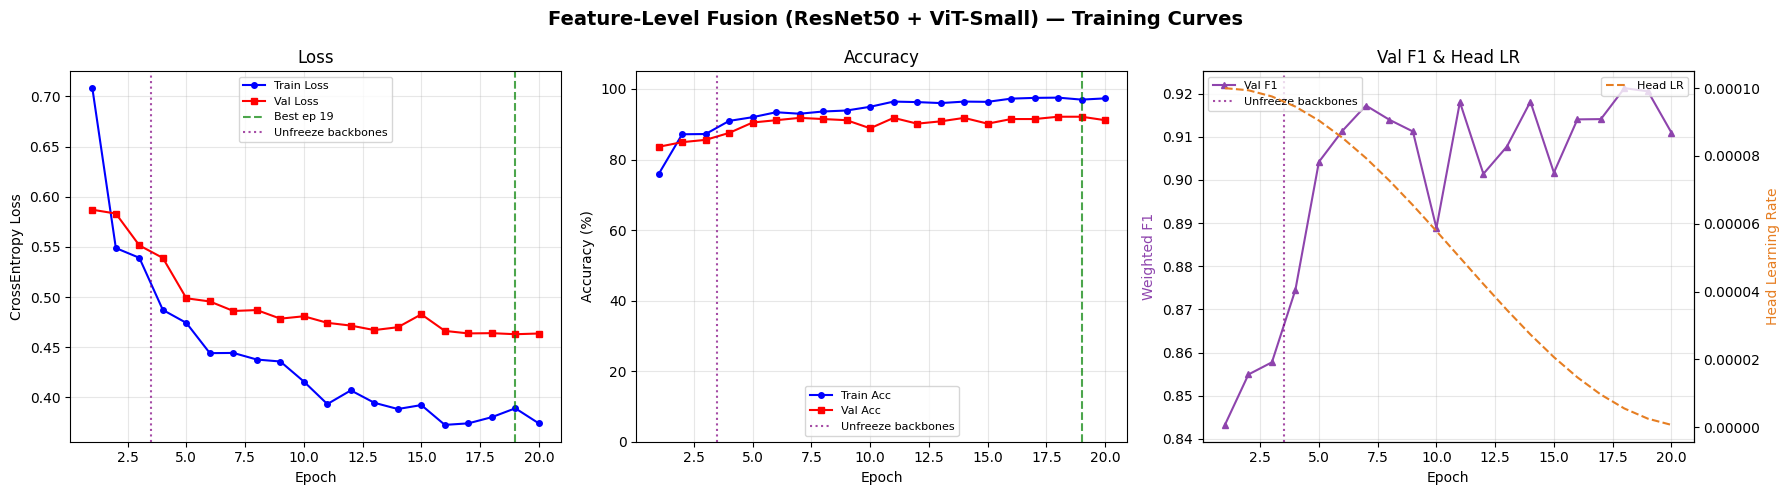


📈 Training Summary:
   Best epoch   : 19
   Best val loss: 0.4630
   Best val acc : 92.13%
   Best val F1  : 0.9213
   Phase transition at epoch 4 (backbones unfrozen)
✅ Step 8 complete.


In [8]:
epochs_ran = list(range(1, len(history["train_loss"]) + 1))

# Identify phase transition point
transition = next((i+1 for i, p in enumerate(history["phase"]) if p == 2), None)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Feature-Level Fusion (ResNet50 + ViT-Small) — Training Curves",
             fontsize=14, fontweight="bold")

def add_phase_line(ax, transition):
    if transition:
        ax.axvline(transition - 0.5, color="purple", linestyle=":",
                   alpha=0.7, linewidth=1.5, label="Unfreeze backbones")

# Loss
ax = axes[0]
ax.plot(epochs_ran, history["train_loss"], "b-o", ms=4, label="Train Loss")
ax.plot(epochs_ran, history["val_loss"],   "r-s", ms=4, label="Val Loss")
best_ep = history["val_loss"].index(min(history["val_loss"])) + 1
ax.axvline(best_ep, color="green", linestyle="--", alpha=0.7, label=f"Best ep {best_ep}")
add_phase_line(ax, transition)
ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("CrossEntropy Loss")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Accuracy
ax2 = axes[1]
ax2.plot(epochs_ran, [v * 100 for v in history["train_acc"]], "b-o", ms=4, label="Train Acc")
ax2.plot(epochs_ran, [v * 100 for v in history["val_acc"]],   "r-s", ms=4, label="Val Acc")
ax2.axvline(best_ep, color="green", linestyle="--", alpha=0.7)
add_phase_line(ax2, transition)
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim([0, 105]); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# F1 + Head LR
ax3 = axes[2]
ax3.plot(epochs_ran, history["val_f1"],   color="#8e44ad", marker="^", ms=4, label="Val F1")
add_phase_line(ax3, transition)
ax3b = ax3.twinx()
ax3b.plot(epochs_ran, history["lr_head"], color="#e67e22", linestyle="--", label="Head LR")
ax3.set_title("Val F1 & Head LR"); ax3.set_xlabel("Epoch")
ax3.set_ylabel("Weighted F1", color="#8e44ad")
ax3b.set_ylabel("Head Learning Rate", color="#e67e22")
ax3.legend(loc="upper left", fontsize=8)
ax3b.legend(loc="upper right", fontsize=8)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step8_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\n📈 Training Summary:")
print(f"   Best epoch   : {best_ep}")
print(f"   Best val loss: {min(history['val_loss']):.4f}")
print(f"   Best val acc : {max(history['val_acc'])*100:.2f}%")
print(f"   Best val F1  : {max(history['val_f1']):.4f}")
if transition:
    print(f"   Phase transition at epoch {transition} (backbones unfrozen)")
print("✅ Step 8 complete.")

---
## ✅ Step 9 — Final Test Evaluation & Metrics

**PDF Phase 6:** Run best model on test set **once only** — report all metrics.

In [9]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print(f"✅ Loaded best checkpoint:")
print(f"   Epoch    : {ckpt['epoch']}")
print(f"   Val loss : {ckpt['val_loss']:.4f}")
print(f"   Val acc  : {ckpt['val_acc']*100:.2f}%")
print(f"   Val F1   : {ckpt['val_f1']:.4f}")
print(f"   Phase    : {ckpt['phase']} ({'Head only' if ckpt['phase']==1 else 'Full finetune'})")

print("\n🔬 Running inference on test set...")
test_loss, test_acc, test_preds, test_true = evaluate(model, test_loader, criterion, DEVICE)

acc_pct      = test_acc * 100
weighted_f1  = f1_score(test_true, test_preds, average="weighted", zero_division=0)
macro_f1     = f1_score(test_true, test_preds, average="macro",    zero_division=0)
per_class_f1 = f1_score(test_true, test_preds, average=None,       zero_division=0)

print("\n" + "=" * 60)
print("  FINAL TEST RESULTS — Feature-Level Fusion (CNN + ViT)")
print("=" * 60)
print(f"  {'Accuracy':<28}{acc_pct:.2f}%")
print(f"  {'Weighted F1':<28}{weighted_f1:.4f}")
print(f"  {'Macro F1':<28}{macro_f1:.4f}")
print(f"  {'Test Loss':<28}{test_loss:.4f}")
print("-" * 60)
print("  Per-Class F1:")
for cls, f1 in zip(CLASS_NAMES, per_class_f1):
    print(f"    {cls:<22} {f1:.4f}  {'█' * int(f1 * 30)}")
print("=" * 60)

print("\n📋 Detailed Classification Report:")
print(classification_report(test_true, test_preds,
                             target_names=CLASS_NAMES, digits=4))

pd.DataFrame({
    "Metric": ["Accuracy", "Weighted F1", "Macro F1"] + [f"F1_{c}" for c in CLASS_NAMES],
    "Value":  [acc_pct/100, weighted_f1, macro_f1] + list(per_class_f1)
}).to_csv(f"/kaggle/working/{PREFIX}_step9_test_results.csv", index=False)
print("\n✅ Step 9 complete — results saved.")

✅ Loaded best checkpoint:
   Epoch    : 19
   Val loss : 0.4630
   Val acc  : 92.13%
   Val F1   : 0.9205
   Phase    : 2 (Full finetune)

🔬 Running inference on test set...

  FINAL TEST RESULTS — Feature-Level Fusion (CNN + ViT)
  Accuracy                    93.81%
  Weighted F1                 0.9384
  Macro F1                    0.9279
  Test Loss                   0.4124
------------------------------------------------------------
  Per-Class F1:
    Healthy_Leaf           0.9560  ████████████████████████████
    Leaf_Rot               0.9024  ███████████████████████████
    Leaf_Spot              0.9252  ███████████████████████████

📋 Detailed Classification Report:
              precision    recall  f1-score   support

Healthy_Leaf     0.9744    0.9383    0.9560       162
    Leaf_Rot     0.9024    0.9024    0.9024        41
   Leaf_Spot     0.9000    0.9519    0.9252       104

    accuracy                         0.9381       307
   macro avg     0.9256    0.9309    0.9279    

---
## ✅ Step 10 — Confusion Matrix & Per-Class Analysis

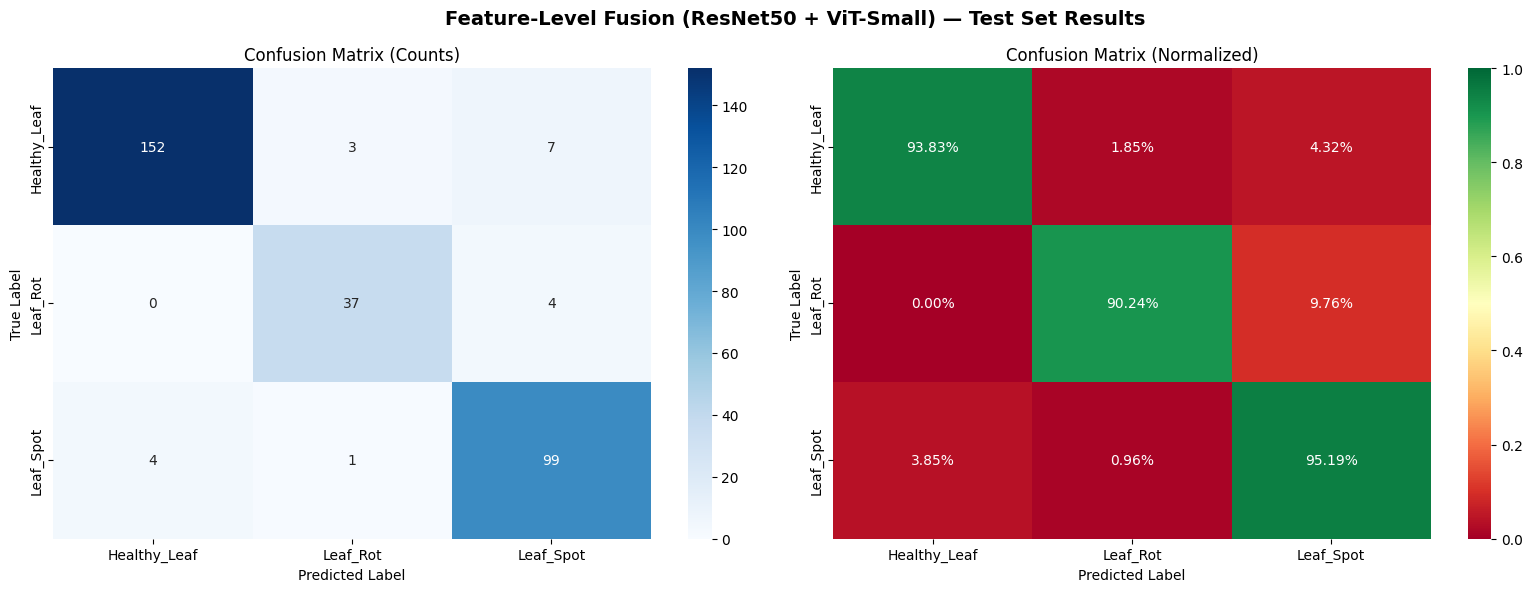

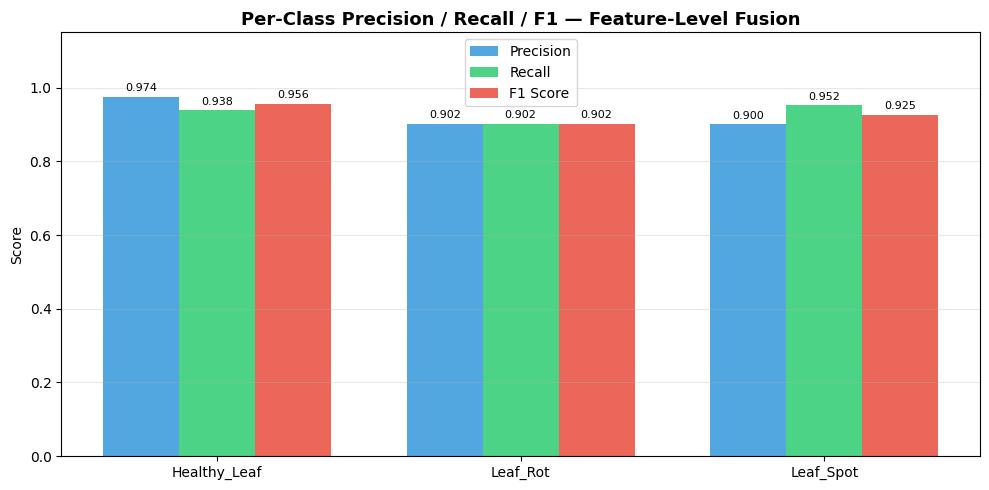

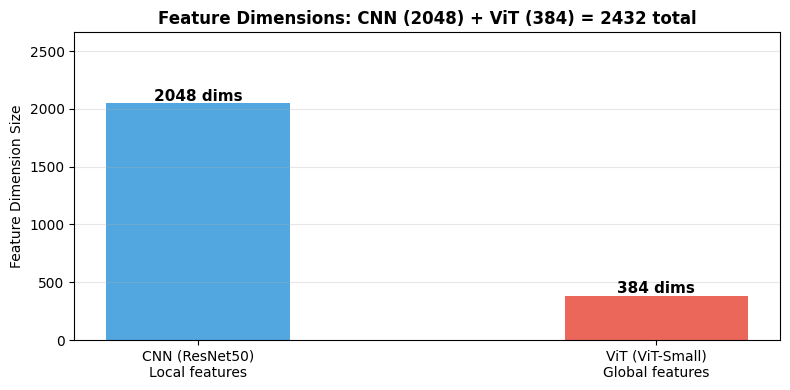


═════════════════════════════════════════════════════════════════
  🌿 FEATURE-LEVEL FUSION (ResNet50 + ViT-Small) — FINAL SUMMARY
═════════════════════════════════════════════════════════════════
  Fusion Method  : Feature-Level Fusion (PDF Experiment B)
  CNN Branch     : ResNet50 (pretrained) → 2048-dim features
  ViT Branch     : ViT-Small/16 (pretrained) → 384-dim features
  Fused Vector   : 2048 + 384 = 2432 dimensions
  Fusion Head    : Linear(2432→512) + ReLU + BN + Dropout → Linear(512→3)
  Input Shape    : [B, 3, 224, 224]
  Classes        : Healthy_Leaf, Leaf_Rot, Leaf_Spot
  Test Accuracy  : 93.81%
  Weighted F1    : 0.9384
  Macro F1       : 0.9279
─────────────────────────────────────────────────────────────────
    Healthy_Leaf        F1=0.9560  Prec=0.9744  Rec=0.9383
    Leaf_Rot            F1=0.9024  Prec=0.9024  Rec=0.9024
    Leaf_Spot           F1=0.9252  Prec=0.9000  Rec=0.9519
─────────────────────────────────────────────────────────────────
  Saved files:
    ✓ 

In [10]:
# ── Confusion Matrix ──────────────────────────────────────────────────────
cm      = confusion_matrix(test_true, test_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Feature-Level Fusion (ResNet50 + ViT-Small) — Test Set Results",
             fontsize=14, fontweight="bold")
sns.heatmap(cm,      annot=True, fmt="d",   cmap="Blues",  ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted Label"); axes[0].set_ylabel("True Label")
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="RdYlGn", ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, vmin=0, vmax=1)
axes[1].set_title("Confusion Matrix (Normalized)")
axes[1].set_xlabel("Predicted Label"); axes[1].set_ylabel("True Label")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step10_confusion_matrix.png",
            dpi=120, bbox_inches="tight")
plt.show()

# ── Per-class Precision / Recall / F1 bar chart ───────────────────────────
per_prec   = precision_score(test_true, test_preds, average=None, zero_division=0)
per_recall = recall_score(test_true,    test_preds, average=None, zero_division=0)

fig2, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CLASS_NAMES)); w = 0.25
b1 = ax.bar(x - w, per_prec,     w, label="Precision", color="#3498db", alpha=0.85)
b2 = ax.bar(x,     per_recall,   w, label="Recall",    color="#2ecc71", alpha=0.85)
b3 = ax.bar(x + w, per_class_f1, w, label="F1 Score",  color="#e74c3c", alpha=0.85)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f"{h:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_title("Per-Class Precision / Recall / F1 — Feature-Level Fusion",
             fontsize=13, fontweight="bold")
ax.set_ylim([0, 1.15]); ax.set_ylabel("Score")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step10_per_class_metrics.png",
            dpi=120, bbox_inches="tight")
plt.show()

# ── Feature contribution visualization ───────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(8, 4))
feature_info = {
    "CNN (ResNet50)\nLocal features": CNN_FEAT_DIM,
    "ViT (ViT-Small)\nGlobal features": VIT_FEAT_DIM
}
bars_f = ax3.bar(feature_info.keys(), feature_info.values(),
                  color=["#3498db", "#e74c3c"], alpha=0.85, width=0.4)
for bar, val in zip(bars_f, feature_info.values()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f"{val} dims", ha="center", fontsize=11, fontweight="bold")
ax3.set_title(f"Feature Dimensions: CNN ({CNN_FEAT_DIM}) + ViT ({VIT_FEAT_DIM}) = {FUSED_DIM} total",
              fontsize=12, fontweight="bold")
ax3.set_ylabel("Feature Dimension Size")
ax3.set_ylim([0, max(CNN_FEAT_DIM, VIT_FEAT_DIM) * 1.3])
ax3.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step10_feature_dims.png",
            dpi=120, bbox_inches="tight")
plt.show()

# ── Final Summary ─────────────────────────────────────────────────────────
print("\n" + "═" * 65)
print("  🌿 FEATURE-LEVEL FUSION (ResNet50 + ViT-Small) — FINAL SUMMARY")
print("═" * 65)
print(f"  Fusion Method  : Feature-Level Fusion (PDF Experiment B)")
print(f"  CNN Branch     : ResNet50 (pretrained) → {CNN_FEAT_DIM}-dim features")
print(f"  ViT Branch     : ViT-Small/16 (pretrained) → {VIT_FEAT_DIM}-dim features")
print(f"  Fused Vector   : {CNN_FEAT_DIM} + {VIT_FEAT_DIM} = {FUSED_DIM} dimensions")
print(f"  Fusion Head    : Linear({FUSED_DIM}→{FUSION_HIDDEN}) + ReLU + BN + Dropout → Linear({FUSION_HIDDEN}→{NUM_CLASSES})")
print(f"  Input Shape    : [B, 3, {IMG_SIZE}, {IMG_SIZE}]")
print(f"  Classes        : {', '.join(CLASS_NAMES)}")
print(f"  Test Accuracy  : {acc_pct:.2f}%")
print(f"  Weighted F1    : {weighted_f1:.4f}")
print(f"  Macro F1       : {macro_f1:.4f}")
print("─" * 65)
for cls, f1, p, r in zip(CLASS_NAMES, per_class_f1, per_prec, per_recall):
    print(f"    {cls:<18}  F1={f1:.4f}  Prec={p:.4f}  Rec={r:.4f}")
print("─" * 65)
print("  Saved files:")
for f in [
    f"{PREFIX}_step3_distribution.png",
    f"{PREFIX}_step4_augmentation.png",
    f"{PREFIX}_step4_architecture.png",
    f"{PREFIX}_step8_training_curves.png",
    f"{PREFIX}_step9_test_results.csv",
    f"{PREFIX}_step10_confusion_matrix.png",
    f"{PREFIX}_step10_per_class_metrics.png",
    f"{PREFIX}_step10_feature_dims.png",
    f"best_{PREFIX}_model.pth"
]:
    print(f"    ✓ /kaggle/working/{f}")
print("═" * 65)
print("  ✅ Step 10 complete — Feature-Level Fusion pipeline finished!")
print("═" * 65)